# Skill

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import calendar

import ocha_stratus as stratus
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score

from src.constants import *

In [3]:
blob_name = f"{PROJECT_PREFIX}/processed/cerf/mrt_drought_allocations.parquet"
df_cerf = stratus.load_parquet_from_blob(blob_name)

In [4]:
blob_name = f"{PROJECT_PREFIX}/processed/asi/mrt_asi_dekadal.parquet"
df_asi = stratus.load_parquet_from_blob(blob_name)
df_asi = df_asi.rename(columns={"Year": "actual_year"})

In [5]:
df_asi

,actual_year,Month,Dekad,asi_all,asi_aoi,date,dekad_overall
0,1984,6,3,0.000000,0.000000,1984-06-21,18
1,1984,7,1,25.656376,47.337759,1984-07-01,19
2,1984,7,2,45.492350,66.030645,1984-07-11,20
3,1984,7,3,44.954676,71.653653,1984-07-21,21
4,1984,8,1,65.741821,82.263089,1984-08-01,22
...,...,...,...,...,...,...,...
1000,2025,12,1,9.423357,25.000000,2025-12-01,34
1001,2025,12,2,13.514330,33.333000,2025-12-11,35
1002,2025,12,3,21.572198,33.333000,2025-12-21,36
1003,2026,1,1,28.882262,33.333000,2026-01-01,1


In [6]:
def calc_asi_year(row):
    if row["dekad_overall"] < 18 and row["dekad_overall"] > 0:
        return row["actual_year"] - 1
    else:
        return row["actual_year"]


df_asi["year"] = df_asi.apply(calc_asi_year, axis=1)

In [7]:
blob_name = f"{PROJECT_PREFIX}/raw/iri/mrt_maproom_export - Sheet1.csv"
df_iri = stratus.load_csv_from_blob(blob_name)

In [8]:
df_iri = df_iri.rename(columns={"Unnamed: 0": "year"})

In [9]:
def emdat_float(row):
    if row["year"] == 2025:
        return np.nan
    if row["EM-DAT Bad Years"] == "Bad":
        return 1
    else:
        return 0


df_iri["emdat_float"] = df_iri.apply(emdat_float, axis=1)

In [10]:
up_cols = [calendar.month_abbr[x] for x in range(1, 7)] + ["emdat_float"]
down_cols = ["Humanitarian Bad Years (rank)", "CHIRPS Precip JAS (mm)"]
all_cols = up_cols + down_cols

df_iri.set_index("year")[all_cols].style.format("{:.0f}").background_gradient(
    subset=up_cols, cmap="RdYlGn_r"
).background_gradient(subset=down_cols, cmap="RdYlGn")

,Jan,Feb,Mar,Apr,May,Jun,emdat_float,Humanitarian Bad Years (rank),CHIRPS Precip JAS (mm)
year,,,,,,,,,
2025,26,28,25,30,23,21,nan,nan,nan
2024,24,24,22,24,25,21,0,30,98
2023,27,27,35,26,32,24,0,30,81
2022,24,23,19,20,19,20,0,30,85
2021,21,15,18,20,19,21,0,10,70
2020,21,18,21,19,19,23,1,16,90
2019,23,28,32,33,30,33,0,8,63
2018,23,26,27,26,26,28,0,30,82
2017,31,39,35,36,32,25,0,6,65


In [11]:
obsv_col = "CHIRPS Precip JAS (mm)"

<Axes: >

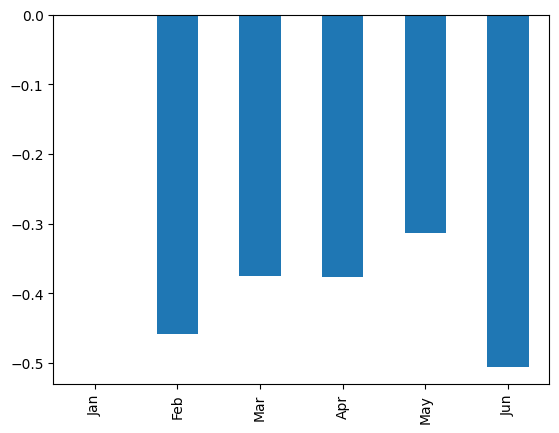

In [12]:
cols = [calendar.month_abbr[mo] for mo in range(1, 7)]
df_iri.corr(numeric_only=True)[obsv_col][cols].plot.bar()

In [13]:
df_iri.corr(numeric_only=True)[obsv_col]

year                             0.235753
Jan                             -0.000218
Feb                             -0.457944
Mar                             -0.374833
Apr                             -0.376571
May                             -0.313008
Jun                             -0.505387
Humanitarian Bad Years (rank)    0.701862
CHIRPS Precip JAS (mm)           1.000000
emdat_float                     -0.012861
Name: CHIRPS Precip JAS (mm), dtype: float64

<Axes: >

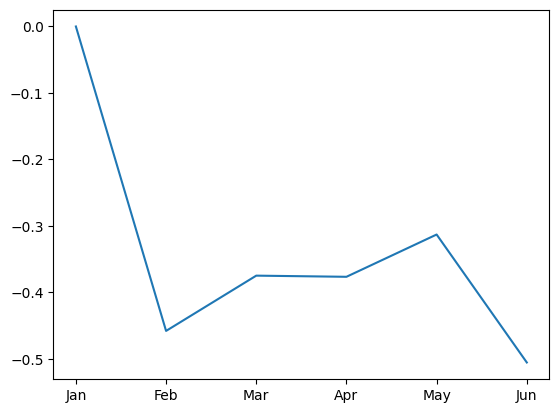

In [14]:
df_iri.corr(numeric_only=True)[obsv_col][cols].plot()

<Axes: >

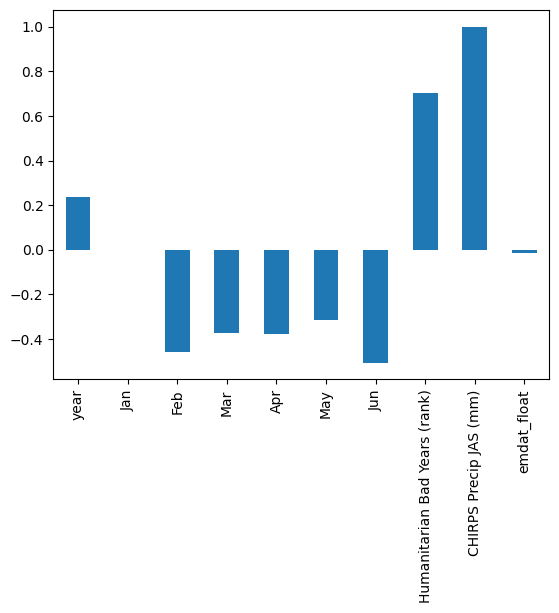

In [15]:
df_iri.corr(numeric_only=True)[obsv_col].plot.bar()

In [16]:
def fill_cerf(row):
    if row["year"] < 2007:
        return np.nan
    elif pd.isna(row["Amount in US$"]):
        return 0
    else:
        return row["Amount in US$"]


df_stats = df_iri.merge(df_cerf[["year", "Amount in US$"]], how="outer")
df_stats["Amount in US$"] = df_stats.apply(fill_cerf, axis=1)

In [19]:
blob_name = f"{PROJECT_PREFIX}/processed/iri_cerf_stats.parquet"
stratus.upload_parquet_to_blob(df_stats, blob_name)

<Axes: >

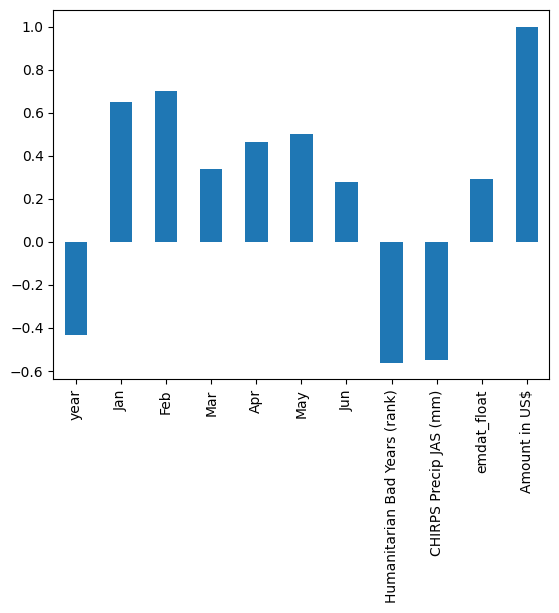

In [17]:
df_stats.corr(numeric_only=True)["Amount in US$"].plot.bar()

In [225]:
df_stats.corr(numeric_only=True)

,year,Jan,Feb,Mar,Apr,May,Jun,Humanitarian Bad Years (rank),CHIRPS Precip JAS (mm),emdat_float,Amount in US$
year,1.000000,-0.701830,-0.577015,-0.477823,-0.440378,-0.541912,-0.709424,0.139911,0.235753,0.100411,-0.434255
Jan,-0.701830,1.000000,0.664619,0.480794,0.487946,0.560542,0.351095,-0.084190,-0.000218,-0.024986,0.650287
Feb,-0.577015,0.664619,1.000000,0.668959,0.724354,0.663206,0.557176,-0.289259,-0.457944,-0.078784,0.702056
Mar,-0.477823,0.480794,0.668959,1.000000,0.628564,0.790385,0.601916,-0.264278,-0.374833,-0.178762,0.336300
Apr,-0.440378,0.487946,0.724354,0.628564,1.000000,0.701620,0.530277,-0.340193,-0.376571,-0.046043,0.464660
May,-0.541912,0.560542,0.663206,0.790385,0.701620,1.000000,0.693906,-0.257628,-0.313008,-0.101272,0.499154
Jun,-0.709424,0.351095,0.557176,0.601916,0.530277,0.693906,1.000000,-0.241621,-0.505387,-0.177513,0.275355
Humanitarian Bad Years (rank),0.139911,-0.084190,-0.289259,-0.264278,-0.340193,-0.257628,-0.241621,1.000000,0.701862,-0.285403,-0.561837
CHIRPS Precip JAS (mm),0.235753,-0.000218,-0.457944,-0.374833,-0.376571,-0.313008,-0.505387,0.701862,1.000000,-0.012861,-0.548520
emdat_float,0.100411,-0.024986,-0.078784,-0.178762,-0.046043,-0.101272,-0.177513,-0.285403,-0.012861,1.000000,0.293248


In [226]:
# min_dekad = 6 * 3 - 2
# max_dekad = 10 * 3
min_dekad = 1
max_dekad = 36

target_cols = [
    "Humanitarian Bad Years (rank)",
    "emdat_float",
    "CHIRPS Precip JAS (mm)",
    "Amount in US$",
]

dicts = []
for dekad in range(min_dekad, max_dekad + 1):
    dff_asi = df_asi[df_asi["dekad_overall"] == dekad]
    _df_compare = dff_asi.merge(df_stats)
    _df_corr = _df_compare.corr(numeric_only=True)
    for target_col in target_cols:
        dicts.append(
            {
                "dekad": dekad,
                "corr_aoi": _df_corr[target_col]["asi_aoi"],
                "corr_all": _df_corr[target_col]["asi_all"],
                "target_col": target_col,
            }
        )

df_corr = pd.DataFrame(dicts)

In [227]:
df_corr[df_corr["dekad"] == 18]

,dekad,corr_aoi,corr_all,target_col
68,18,-0.258285,-0.286825,Humanitarian Bad Years (rank)
69,18,-0.150468,-0.144623,emdat_float
70,18,-0.465000,-0.502247,CHIRPS Precip JAS (mm)
71,18,-0.125275,-0.101273,Amount in US$


In [228]:
df_corr[df_corr["dekad"] == 6]

,dekad,corr_aoi,corr_all,target_col
20,6,NaN,NaN,Humanitarian Bad Years (rank)
21,6,NaN,NaN,emdat_float
22,6,NaN,NaN,CHIRPS Precip JAS (mm)
23,6,NaN,NaN,Amount in US$


In [229]:
df_corr

,dekad,corr_aoi,corr_all,target_col
0,1,0.008956,-0.260659,Humanitarian Bad Years (rank)
1,1,0.245081,0.130241,emdat_float
2,1,-0.181138,-0.501335,CHIRPS Precip JAS (mm)
3,1,-0.385742,-0.043069,Amount in US$
4,2,0.033259,-0.267067,Humanitarian Bad Years (rank)
...,...,...,...,...
139,35,-0.276102,-0.099115,Amount in US$
140,36,0.066839,-0.220089,Humanitarian Bad Years (rank)
141,36,0.144524,0.084226,emdat_float
142,36,-0.331468,-0.534349,CHIRPS Precip JAS (mm)


In [230]:
target_col_replace = {
    "Amount in US$": "Allocations CERF",
    "emdat_float": "EM-DAT (binaire)",
}

In [231]:
import calendar

flip_targets = {
    "CHIRPS Precip JAS (mm)",
    "Humanitarian Bad Years (rank)",
}

# ------------------------
# Prepare plotting dataframe (same as before)
# ------------------------
df_plot = df_corr[(df_corr["dekad"] >= 18) | (df_corr["dekad"] <= 5)].copy()

df_plot["dekad_wrapped"] = df_plot["dekad"]
df_plot.loc[df_plot["dekad"] <= 5, "dekad_wrapped"] += 36

# flip correlations where needed
mask = df_plot["target_col"].isin(flip_targets)
df_plot.loc[mask, ["corr_all", "corr_aoi"]] *= -1

df_plot["target_col_rename"] = df_plot["target_col"].replace(
    target_col_replace
)

ymin = df_plot[["corr_all", "corr_aoi"]].min().min()
ymax = df_plot[["corr_all", "corr_aoi"]].max().max()


# ------------------------
# Helper: draw one panel
# ------------------------
def plot_panel(df_plot, value_col, title):
    fig, ax = plt.subplots(figsize=(11, 7), dpi=200)

    # plot each target series
    for target_col, group in df_plot.groupby("target_col_rename"):
        g = group.sort_values("dekad_wrapped")
        ax.plot(
            g["dekad_wrapped"],
            g[value_col],
            label=target_col,
        )

    # ---- mean line (black) ----
    mean_series = (
        df_plot.groupby("dekad_wrapped")[value_col].mean().sort_index()
    )

    ax.plot(
        mean_series.index,
        mean_series.values,
        color="black",
        linewidth=2.5,
        label="Moyenne",
    )

    # ------------------------
    # X ticks: dekads
    # ------------------------
    xticks = sorted(df_plot["dekad_wrapped"].unique())
    xtick_labels = [str(d - 36 if d > 36 else d) for d in xticks]

    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels)
    ax.set_xlim(min(xticks), max(xticks))

    ax.set_xlabel("Dékade")
    ax.set_ylabel("Corrélation")
    ax.set_title(title)

    # ------------------------
    # Month boundary lines (between dekads)
    # ------------------------
    month_boundaries = [d for d in range(3, 37, 3)]

    wrapped_bounds = []
    for d in month_boundaries:
        if d >= 18:
            wrapped_bounds.append(d)
        elif d <= 5:
            wrapped_bounds.append(d + 36)

    for xb in wrapped_bounds:
        ax.axvline(xb + 0.5, linewidth=0.6, alpha=0.25)

    # ------------------------
    # Month labels under axis
    # ------------------------
    def dekad_to_month(d):
        return ((d - 1) // 3) + 1

    dekads_shown = sorted(df_plot["dekad"].unique())
    months_shown = sorted({dekad_to_month(d) for d in dekads_shown})

    for m in months_shown:
        ds = [d for d in dekads_shown if dekad_to_month(d) == m]
        wrapped = [(d if d >= 18 else d + 36) for d in ds]
        center = sum(wrapped) / len(wrapped)

        ax.text(
            center,
            -0.05,
            calendar.month_abbr[m],
            ha="center",
            va="top",
            transform=ax.get_xaxis_transform(),
            fontsize=9,
        )

    ax.xaxis.labelpad = 18
    plt.subplots_adjust(bottom=0.18)

    # ------------------------
    # Legend outside
    # ------------------------
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
    )

    ax.set_ylim(ymin, ymax)
    ax.axhline(0, linewidth=0.5, color="k")

    fig.tight_layout()

    [ax.spines[x].set_visible(False) for x in ["top", "right"]]
    return fig, ax

(<Figure size 2200x1400 with 1 Axes>,
 <Axes: title={'center': 'Correlation avec ASI dékadal (tout pays)'}, xlabel='Dékade', ylabel='Corrélation'>)

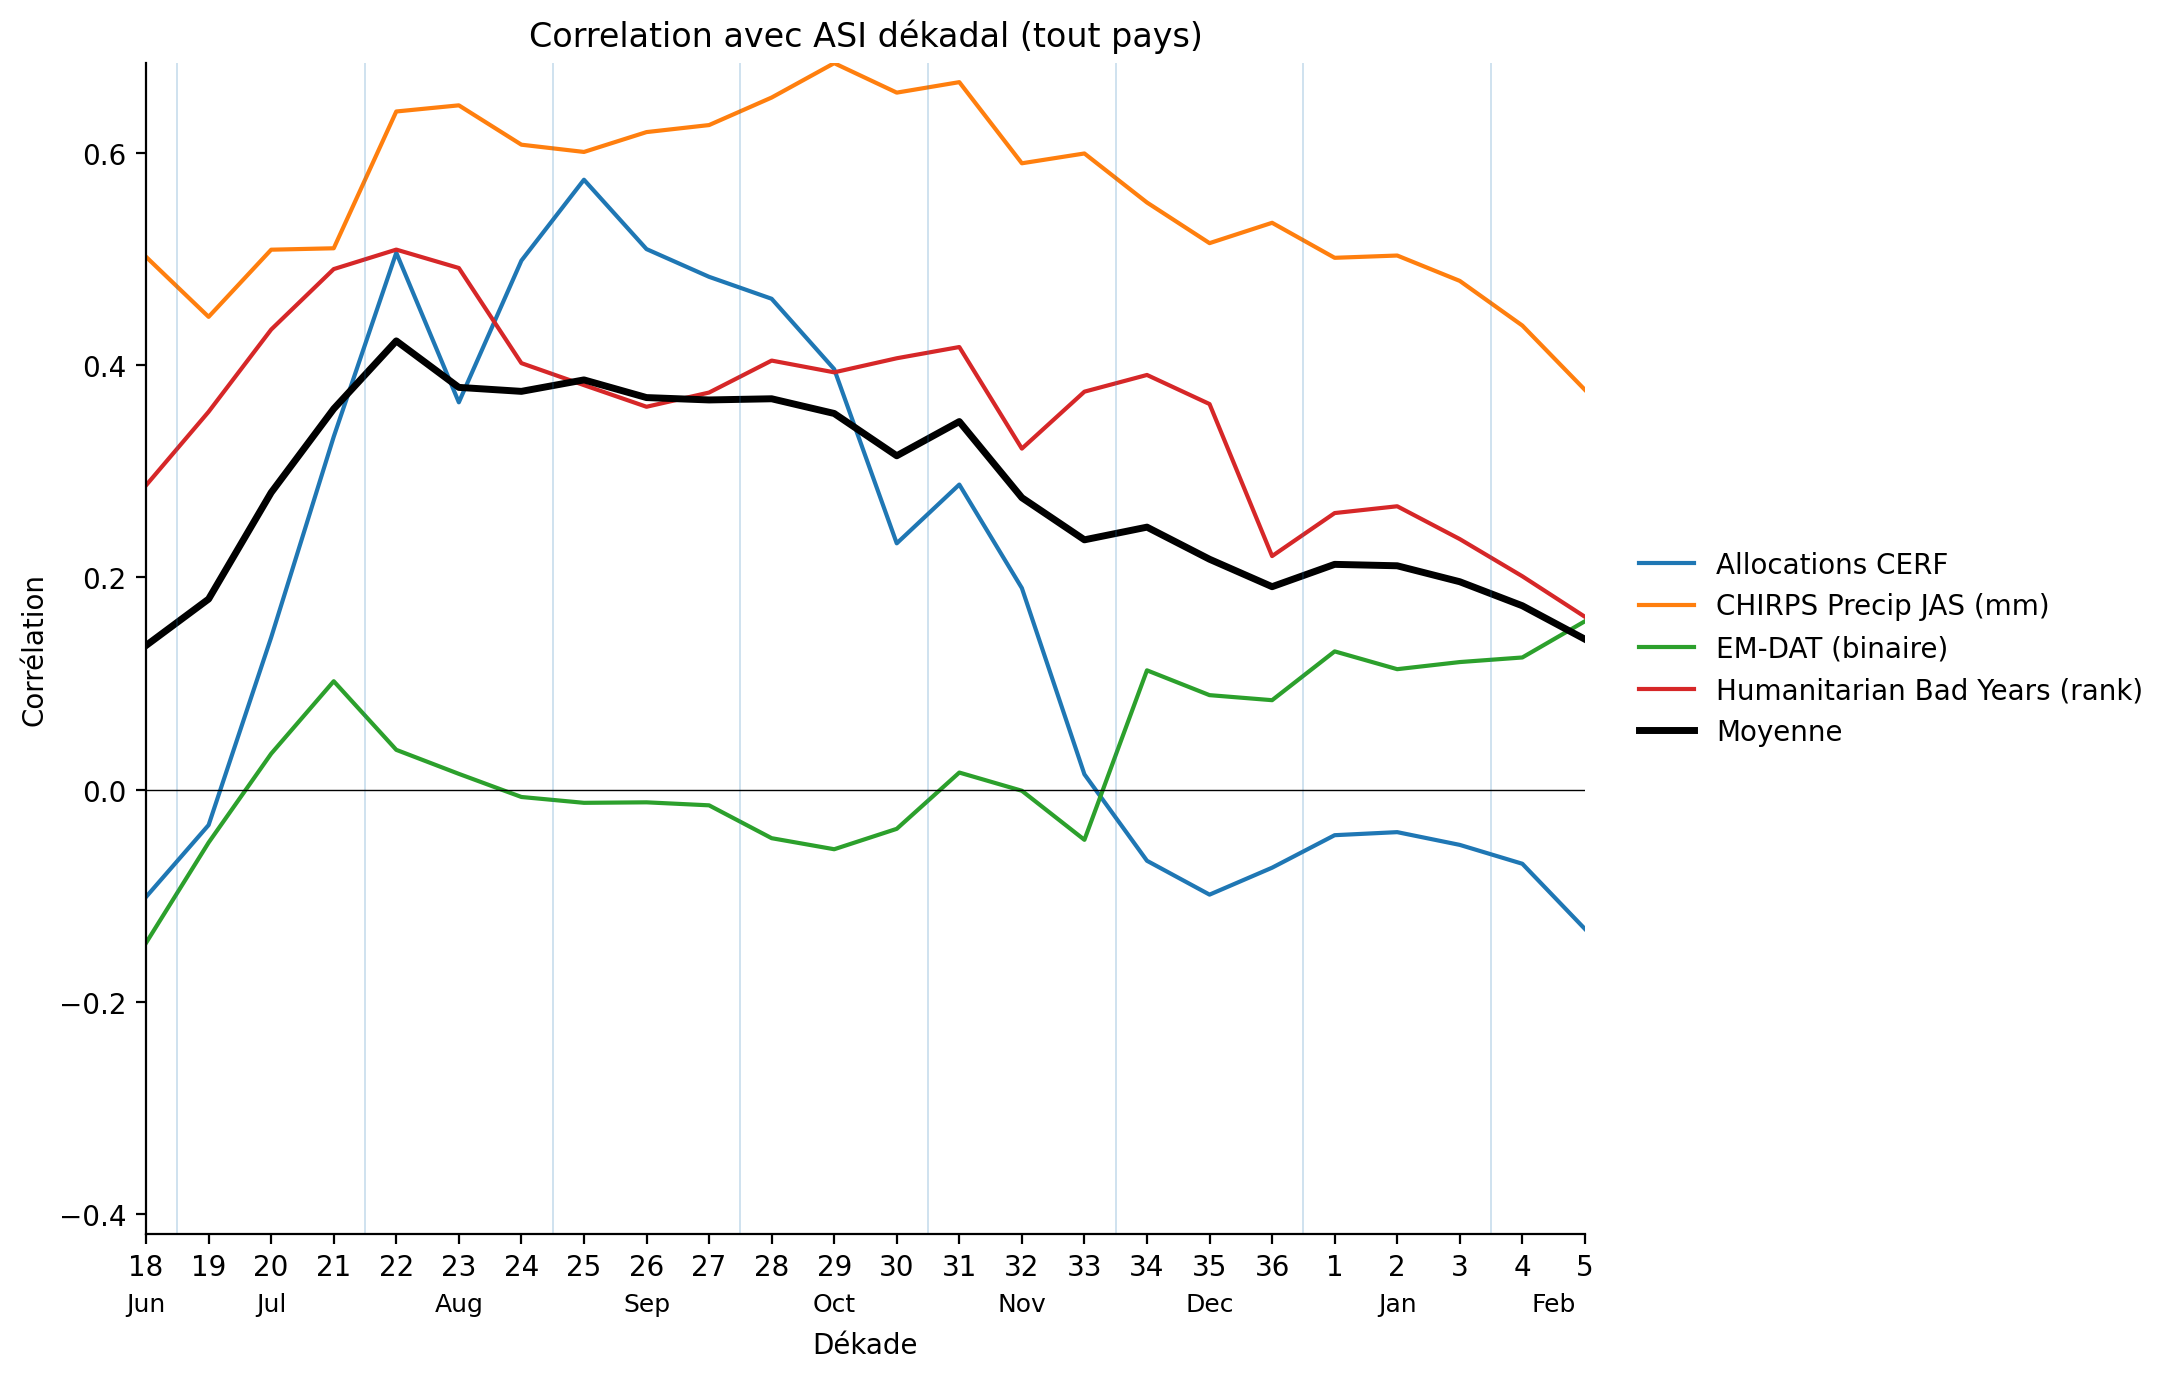

In [232]:
plot_panel(df_plot, "corr_all", "Correlation avec ASI dékadal (tout pays)")

(<Figure size 2200x1400 with 1 Axes>,
 <Axes: title={'center': 'Correlation avec ASI dékadal (AOI seulement)'}, xlabel='Dékade', ylabel='Corrélation'>)

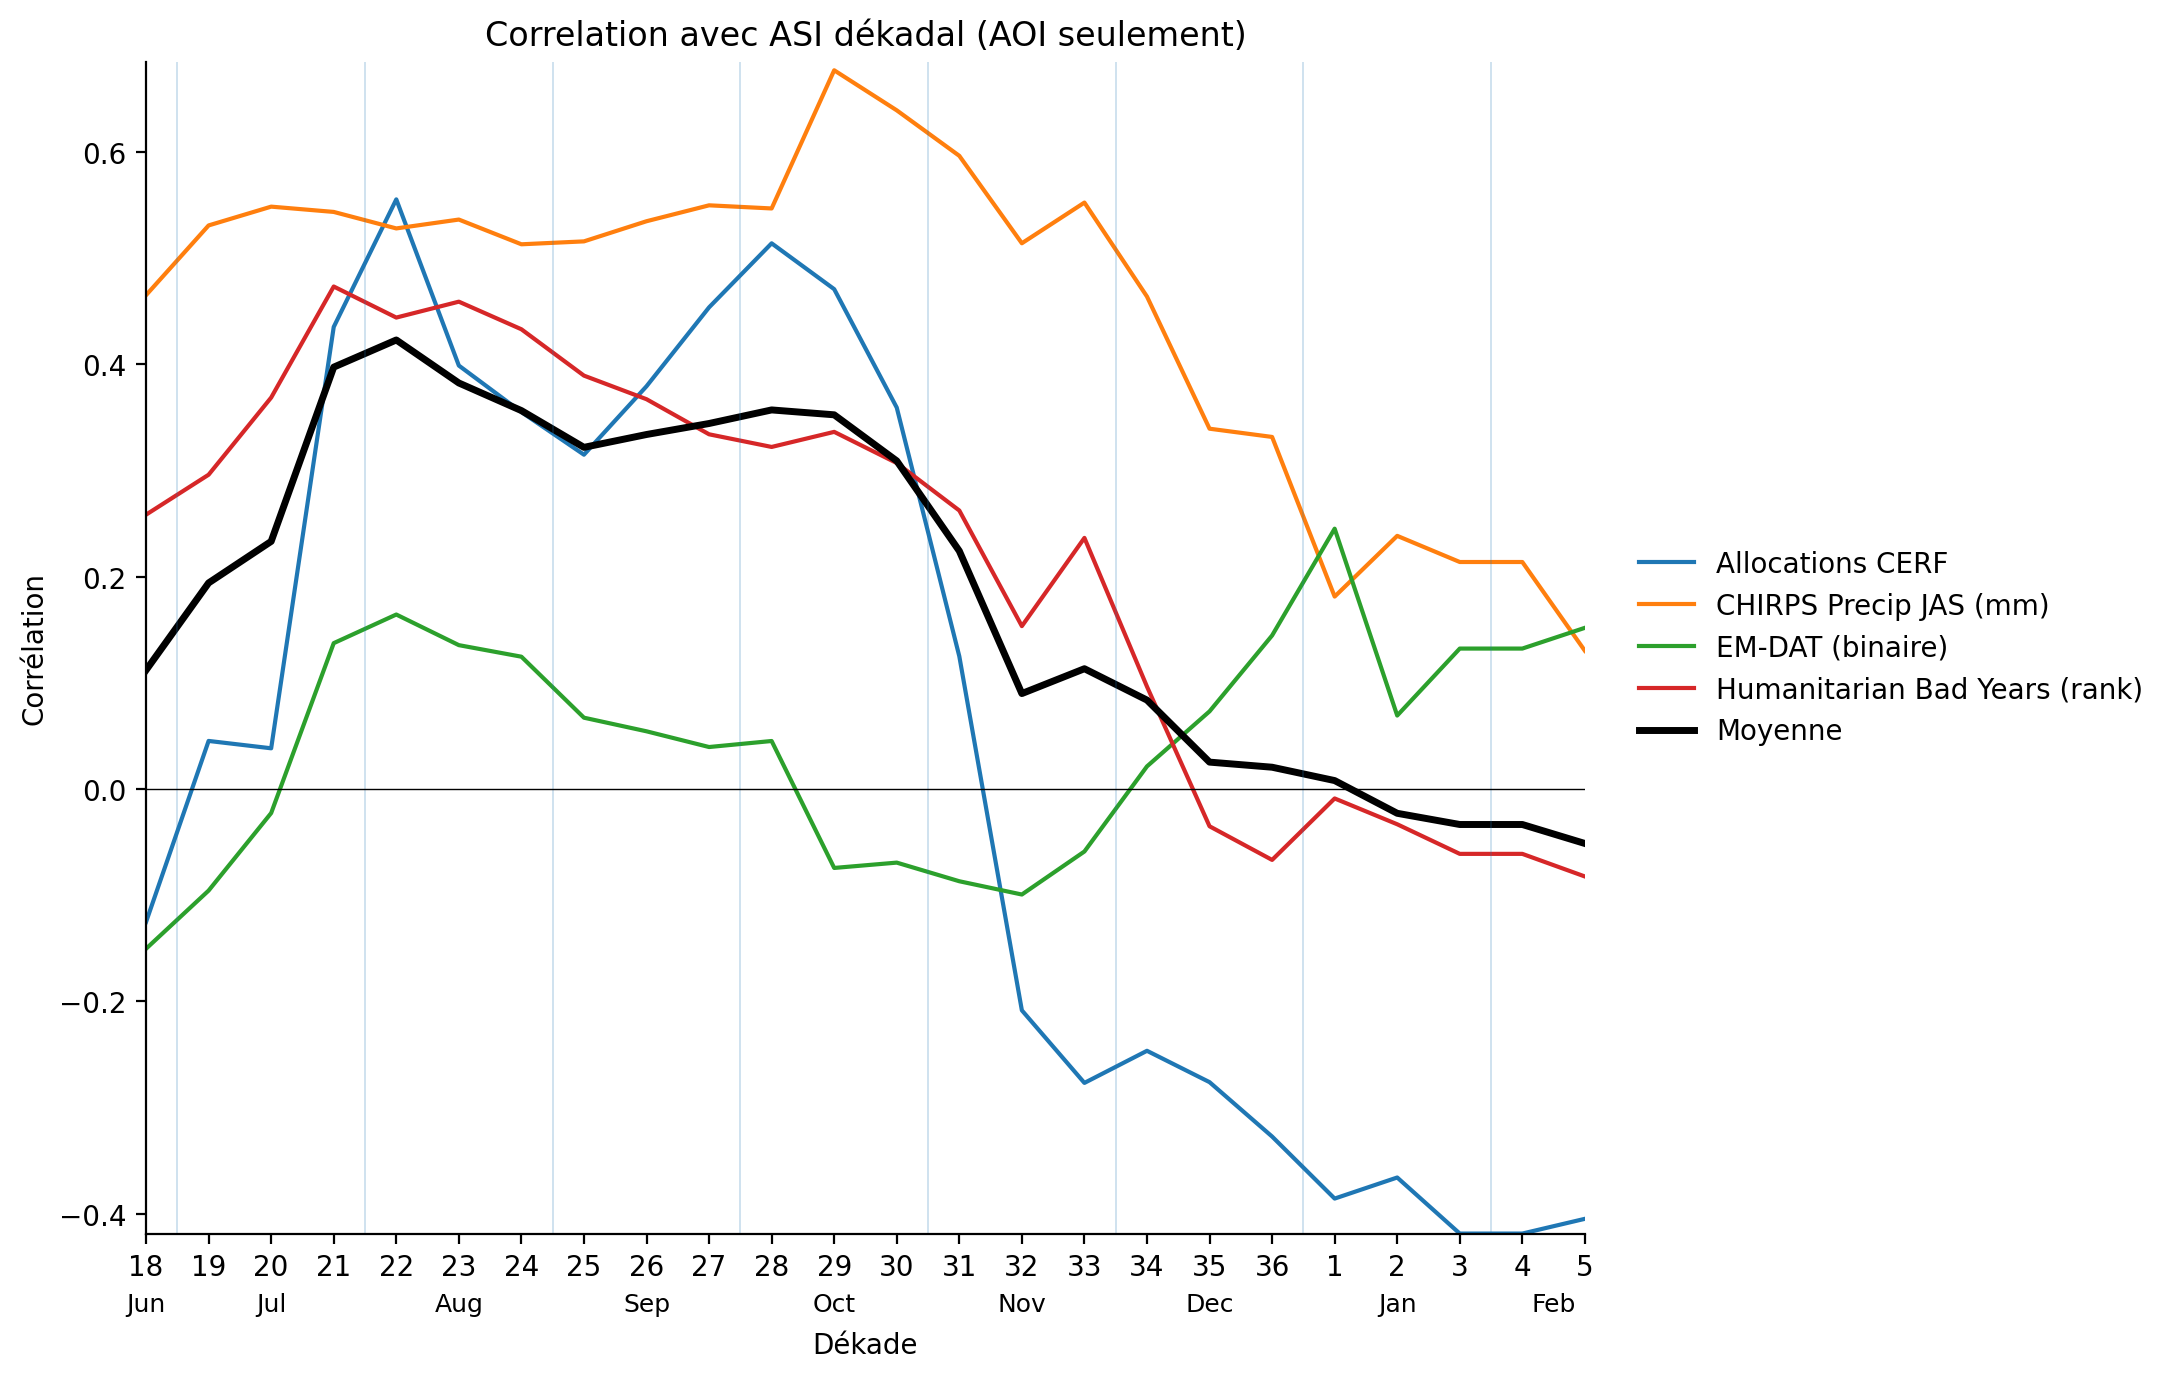

In [233]:
plot_panel(df_plot, "corr_aoi", "Correlation avec ASI dékadal (AOI seulement)")

In [279]:
min_dekad = 21
max_dekad = 28

df_asi_limited = df_asi[
    (df_asi["dekad_overall"] >= min_dekad)
    & (df_asi["dekad_overall"] <= max_dekad)
]

df_asi_yearly = (
    df_asi_limited.groupby("year")[["asi_all", "asi_aoi"]].max().reset_index()
)

In [280]:
df_stats_asi = df_stats.merge(df_asi_yearly)

In [281]:
df_stats_asi

,year,Jan,Feb,Mar,Apr,May,Jun,Humanitarian Bad Years (rank),EM-DAT Bad Years,CHIRPS Precip JAS (mm),emdat_float,Amount in US$,asi_all,asi_aoi
0,1991,29.4,31.0,31.9,32.6,30.5,42.3,16.0,NaN,62.1,0.0,NaN,80.119618,77.376939
1,1992,30.0,41.7,38.5,46.7,39.3,40.1,16.0,NaN,53.4,0.0,NaN,37.153732,45.438433
2,1993,32.6,37.6,33.9,37.2,38.3,47.5,16.0,NaN,70.4,0.0,NaN,7.121352,25.996007
3,1994,32.3,32.8,35.3,42.0,43.8,39.4,16.0,NaN,80.7,0.0,NaN,0.292771,0.000000
4,1995,33.7,31.6,24.5,30.8,31.3,27.2,16.0,NaN,91.1,0.0,NaN,10.773393,0.151208
5,1996,37.6,39.3,34.1,43.2,31.6,33.0,16.0,NaN,60.7,0.0,NaN,34.921136,12.025221
6,1997,34.2,39.6,42.4,28.9,36.1,41.3,16.0,NaN,71.2,0.0,NaN,50.056611,62.475805
7,1998,32.8,26.8,33.0,25.8,30.6,27.5,16.0,NaN,85.0,0.0,NaN,1.538042,0.529227
8,1999,36.3,31.3,35.8,40.3,27.5,25.7,30.0,NaN,99.1,0.0,NaN,0.078467,0.000000
9,2000,36.1,32.9,32.5,27.7,35.4,28.0,16.0,NaN,76.7,0.0,NaN,8.676222,0.756039


In [282]:
df_stats.set_index("year").corr(numeric_only=True)

,Jan,Feb,Mar,Apr,May,Jun,Humanitarian Bad Years (rank),CHIRPS Precip JAS (mm),emdat_float,Amount in US$
Jan,1.000000,0.664619,0.480794,0.487946,0.560542,0.351095,-0.084190,-0.000218,-0.024986,0.650287
Feb,0.664619,1.000000,0.668959,0.724354,0.663206,0.557176,-0.289259,-0.457944,-0.078784,0.702056
Mar,0.480794,0.668959,1.000000,0.628564,0.790385,0.601916,-0.264278,-0.374833,-0.178762,0.336300
Apr,0.487946,0.724354,0.628564,1.000000,0.701620,0.530277,-0.340193,-0.376571,-0.046043,0.464660
May,0.560542,0.663206,0.790385,0.701620,1.000000,0.693906,-0.257628,-0.313008,-0.101272,0.499154
Jun,0.351095,0.557176,0.601916,0.530277,0.693906,1.000000,-0.241621,-0.505387,-0.177513,0.275355
Humanitarian Bad Years (rank),-0.084190,-0.289259,-0.264278,-0.340193,-0.257628,-0.241621,1.000000,0.701862,-0.285403,-0.561837
CHIRPS Precip JAS (mm),-0.000218,-0.457944,-0.374833,-0.376571,-0.313008,-0.505387,0.701862,1.000000,-0.012861,-0.548520
emdat_float,-0.024986,-0.078784,-0.178762,-0.046043,-0.101272,-0.177513,-0.285403,-0.012861,1.000000,0.293248
Amount in US$,0.650287,0.702056,0.336300,0.464660,0.499154,0.275355,-0.561837,-0.548520,0.293248,1.000000


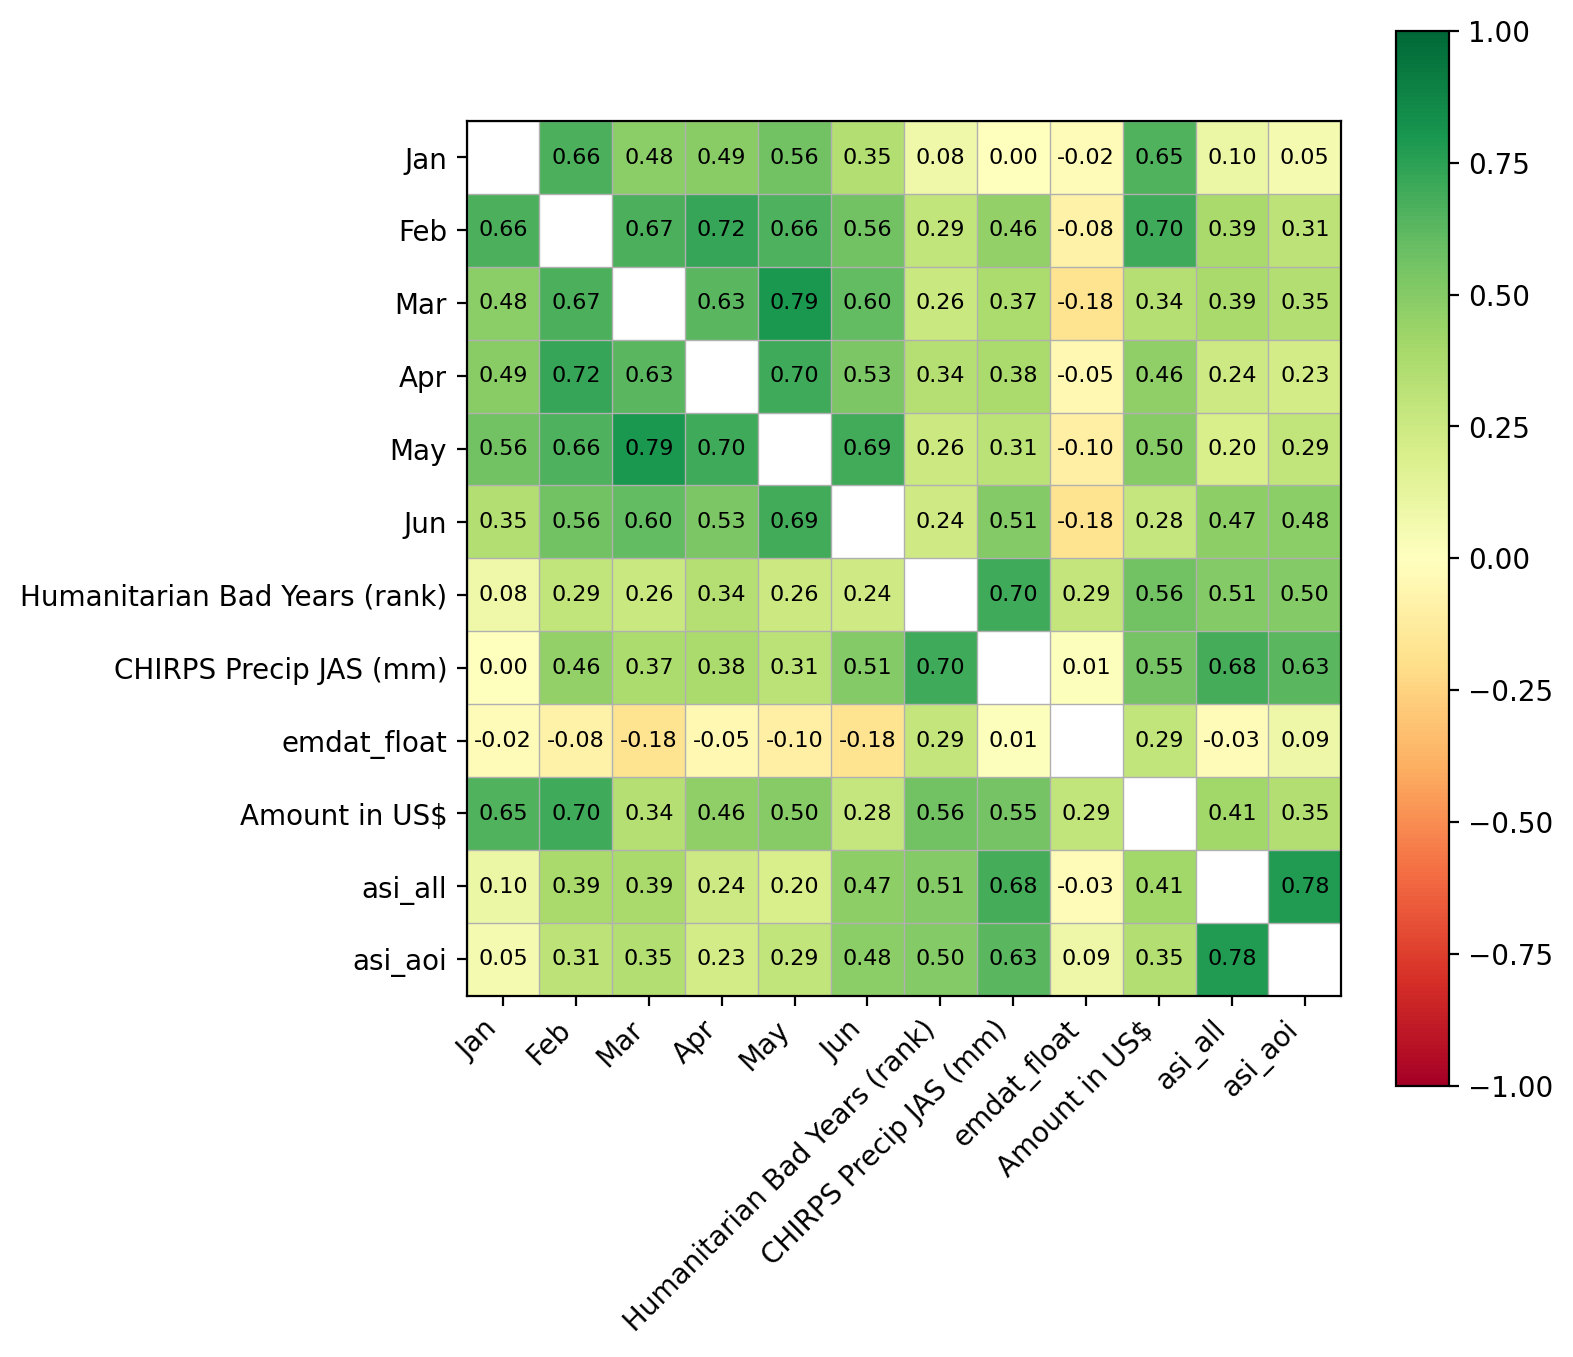

In [291]:
flip_targets = {
    "CHIRPS Precip JAS (mm)",
    "Humanitarian Bad Years (rank)",
}

df_corr = df_stats_asi.set_index("year").copy()
df_corr[list(flip_targets)] *= -1

corr = df_corr.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 8), dpi=200)

corr_plot = corr.copy()
np.fill_diagonal(corr_plot.values, np.nan)

cmap = plt.get_cmap("RdYlGn").copy()
cmap.set_bad(color="white")

im = ax.imshow(
    corr_plot.values,
    vmin=-1,
    vmax=1,
    cmap=cmap,
)

# ticks and labels
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

# force square cells
ax.set_aspect("equal")

# grid lines
ax.set_xticks(np.arange(-0.5, len(corr.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(corr.index), 1), minor=True)
ax.grid(which="minor", linestyle="-", linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)

# annotate values (rounded to 2 decimals)
for i in range(corr_plot.shape[0]):
    for j in range(corr_plot.shape[1]):
        val = corr_plot.iloc[i, j]
        if not np.isnan(val):
            ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=8,
            )

if not np.isnan(val):
    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()

In [260]:
flip_targets = {
    "CHIRPS Precip JAS (mm)",
    "Humanitarian Bad Years (rank)",
}

df_scores = df_stats_asi.set_index("year").copy()

# flip so higher is always "better"
df_scores[list(flip_targets)] *= -1

# keep only numeric columns
df_scores = df_scores.select_dtypes(include="number")

# binarize: 1 if in upper quartile of that column
binary = pd.DataFrame(
    {
        col: (df_scores[col] >= df_scores[col].quantile(0.75)).astype(int)
        for col in df_scores.columns
    },
    index=df_scores.index,
)

# pairwise F1 matrix
f1_mat = pd.DataFrame(
    np.nan,
    index=binary.columns,
    columns=binary.columns,
)

for col_i in binary.columns:
    for col_j in binary.columns:
        f1_mat.loc[col_i, col_j] = f1_score(binary[col_i], binary[col_j])

# use f1_mat instead of corr in the heatmap
corr = f1_mat

In [261]:
corr

,Jan,Feb,Mar,Apr,May,Jun,Humanitarian Bad Years (rank),CHIRPS Precip JAS (mm),emdat_float,Amount in US$,asi_all,asi_aoi
Jan,1.000000,0.333333,0.333333,0.333333,0.210526,0.222222,0.222222,0.222222,0.418605,0.285714,0.333333,0.222222
Feb,0.333333,1.000000,0.444444,0.666667,0.421053,0.444444,0.333333,0.666667,0.418605,0.428571,0.555556,0.555556
Mar,0.333333,0.444444,1.000000,0.444444,0.526316,0.444444,0.444444,0.444444,0.418605,0.285714,0.555556,0.444444
Apr,0.333333,0.666667,0.444444,1.000000,0.526316,0.444444,0.333333,0.555556,0.418605,0.285714,0.444444,0.444444
May,0.210526,0.421053,0.526316,0.526316,1.000000,0.736842,0.315789,0.315789,0.454545,0.266667,0.421053,0.526316
Jun,0.222222,0.444444,0.444444,0.444444,0.736842,1.000000,0.111111,0.444444,0.418605,0.142857,0.555556,0.555556
Humanitarian Bad Years (rank),0.222222,0.333333,0.444444,0.333333,0.315789,0.111111,1.000000,0.555556,0.418605,0.428571,0.444444,0.555556
CHIRPS Precip JAS (mm),0.222222,0.666667,0.444444,0.555556,0.315789,0.444444,0.555556,1.000000,0.418605,0.428571,0.666667,0.666667
emdat_float,0.418605,0.418605,0.418605,0.418605,0.454545,0.418605,0.418605,0.418605,1.000000,0.256410,0.418605,0.418605
Amount in US$,0.285714,0.428571,0.285714,0.285714,0.266667,0.142857,0.428571,0.428571,0.256410,1.000000,0.142857,0.285714


In [292]:
base = df_stats_asi.sort_values("year", ascending=False).set_index("year")[
    all_cols
]

styled = (
    base.style.format("{:.0f}", subset=all_cols, na_rep="")
    .background_gradient(subset=up_cols, cmap="RdYlGn_r")
    .background_gradient(subset=down_cols, cmap="RdYlGn")
    .map(
        lambda v: "background-color: white" if pd.isna(v) else "",
        subset=all_cols,
    )
)

styled

,Jan,Feb,Mar,Apr,May,Jun,emdat_float,asi_all,asi_aoi,Amount in US$,Humanitarian Bad Years (rank),CHIRPS Precip JAS (mm)
year,,,,,,,,,,,,
2025,26,28,25,30,23,21,,4,0,0,,
2024,24,24,22,24,25,21,0,2,1,0,30,98
2023,27,27,35,26,32,24,0,3,0,0,30,81
2022,24,23,19,20,19,20,0,2,1,0,30,85
2021,21,15,18,20,19,21,0,30,39,0,10,70
2020,21,18,21,19,19,23,1,1,0,0,16,90
2019,23,28,32,33,30,33,0,33,47,0,8,63
2018,23,26,27,26,26,28,0,10,0,0,30,82
2017,31,39,35,36,32,25,0,26,5,3975873,6,65


In [12]:
rp_ind = 4

In [13]:
thresh_obsv = df_iri[obsv_col].quantile(1 / rp_ind)

In [14]:
thresh_obsv

np.float64(69.575)

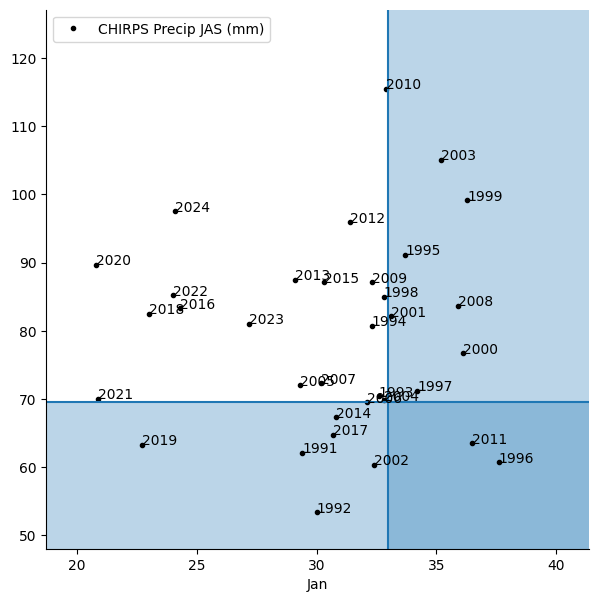

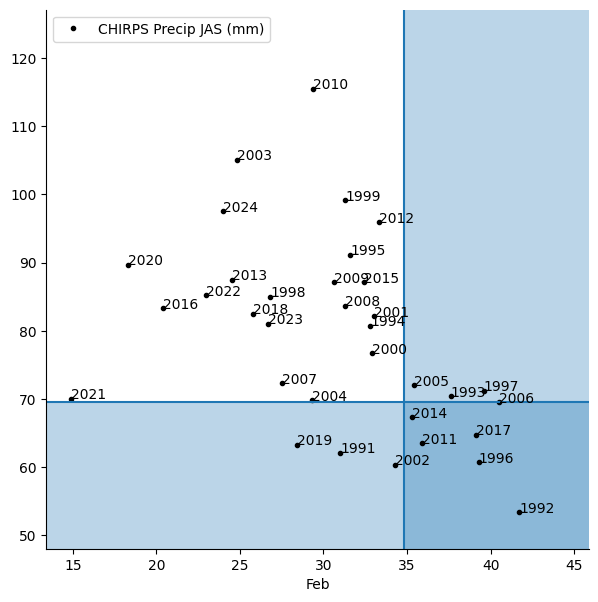

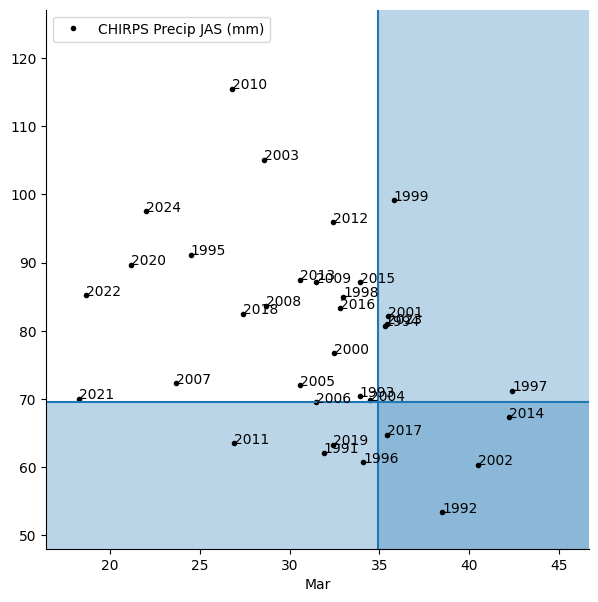

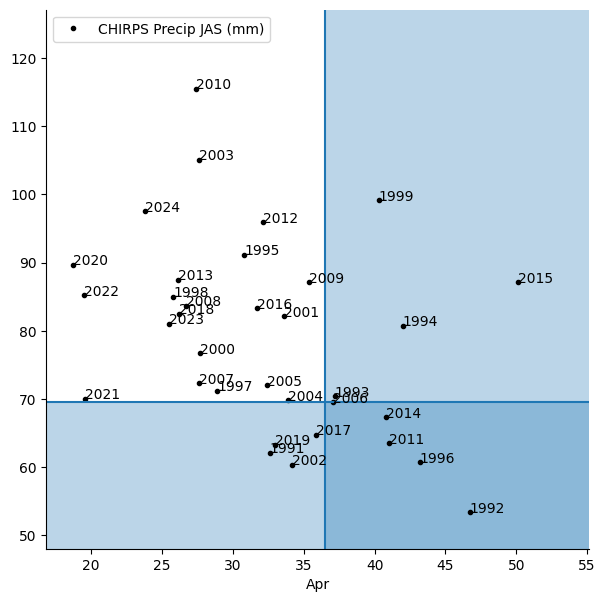

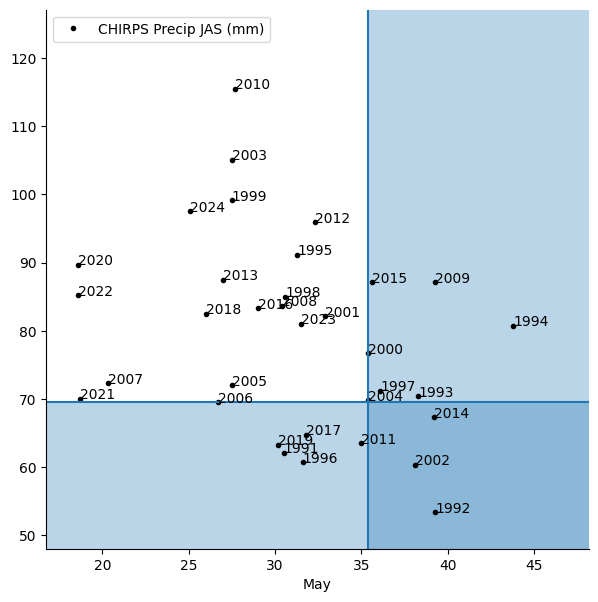

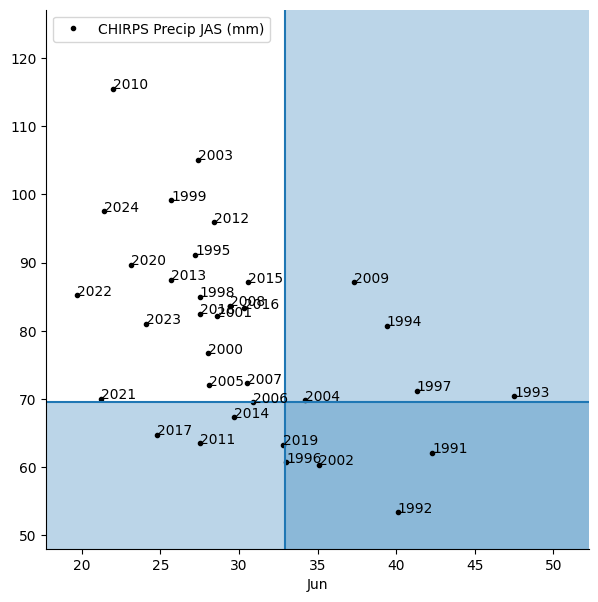

In [263]:
ymin = df_iri[obsv_col].min() * 0.9
ymax = df_iri[obsv_col].max() * 1.1

fcast_cols = [calendar.month_abbr[x] for x in range(1, 7)]


for col in fcast_cols:
    fig, ax = plt.subplots(figsize=(7, 7))
    df_iri.plot(x=col, y=obsv_col, ax=ax, linewidth=0, marker=".", color="k")
    for _, row in df_iri.iterrows():
        ax.annotate(row["year"], row[[col, obsv_col]])

    thresh_fcast = df_iri[col].quantile(1 - 1 / rp_ind)

    xmin = df_iri[col].min() * 0.9
    xmax = df_iri[col].max() * 1.1

    ax.axhline(thresh_obsv)
    ax.axhspan(ymin=ymin, ymax=thresh_obsv, alpha=0.3)

    ax.axvline(thresh_fcast)
    ax.axvspan(xmin=thresh_fcast, xmax=xmax, alpha=0.3)

    ax.set_xlim((xmin, xmax))
    ax.set_ylim((ymin, ymax))

    [ax.spines[x].set_visible(False) for x in ["top", "right"]]